In [1]:
# =========================
# Cell 0. 环境配置
# =========================

import sys
import subprocess
import importlib.util


def pip_install(package: str):
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        package,
    ])


# OpenCV 在 kaggle 环境里不一定有，使用 headless 版本即可
if importlib.util.find_spec("cv2") is None:
    pip_install("opencv-python-headless")

# 常规依赖
for pkg, import_name in [
    ("pillow", "PIL"),
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("tqdm", "tqdm"),
]:
    if importlib.util.find_spec(import_name) is None:
        pip_install(pkg)

print("环境依赖检查完成")

DEBUG = False


环境依赖检查完成


In [2]:
# =========================
# Cell 1. 导入库与扫描视频
# =========================

import os
import cv2
import json
import math
import hashlib
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List

import pandas as pd
import numpy as np
from tqdm import tqdm

import kaggle_benchmarks as kbench
from kaggle_benchmarks.content_types import images


INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working")
STORYBOARD_DIR = WORK_ROOT / "storyboards"
RESULT_DIR = WORK_ROOT / "results"

STORYBOARD_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

VIDEO_EXTS = {".mp4", ".mov", ".mkv", ".avi", ".webm"}


def find_video_files(input_root: Path = INPUT_ROOT) -> List[str]:
    video_files = []
    for p in input_root.rglob("*"):
        if p.is_file() and p.suffix.lower() in VIDEO_EXTS:
            video_files.append(str(p))
    return sorted(video_files)


video_files = find_video_files()

print(f"找到视频数量: {len(video_files)}")
for p in video_files[:30]:
    print(p)

找到视频数量: 4
/kaggle/input/datasets/chrisezadi/together/part1.mp4
/kaggle/input/datasets/chrisezadi/together/part2.mp4
/kaggle/input/datasets/chrisezadi/together/part3.mp4
/kaggle/input/datasets/chrisezadi/together/part4.mp4


In [3]:
# =========================
# Cell 2. 视频元信息读取
# =========================

def probe_video(video_path: str) -> dict:
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError(f"无法打开视频: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    duration = total_frames / fps if fps and fps > 0 else 0.0

    cap.release()

    return {
        "video_path": video_path,
        "fps": fps,
        "total_frames": total_frames,
        "duration": duration,
        "width": width,
        "height": height,
    }


if video_files:
    info = probe_video(video_files[0])
    print(json.dumps(info, indent=2, ensure_ascii=False))

{
  "video_path": "/kaggle/input/datasets/chrisezadi/together/part1.mp4",
  "fps": 29.9990566334392,
  "total_frames": 63600,
  "duration": 2120.0666666666666,
  "width": 1280,
  "height": 720
}


In [4]:
# =========================
# Cell 3. 抽关键帧并拼成 storyboard
# =========================

def safe_video_id(video_path: str) -> str:
    name = Path(video_path).stem
    digest = hashlib.md5(video_path.encode("utf-8")).hexdigest()[:8]
    return f"{name}_{digest}"


def read_frame_at_time(cap, fps: float, timestamp: float):
    frame_idx = int(timestamp * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    ok, frame = cap.read()
    if not ok:
        return None

    return frame


def resize_keep_ratio(frame, target_width: int = 320):
    h, w = frame.shape[:2]
    if w <= 0 or h <= 0:
        return frame

    scale = target_width / w
    target_height = max(1, int(h * scale))
    return cv2.resize(frame, (target_width, target_height))


def draw_timestamp(frame, timestamp: float):
    label = f"{timestamp:.1f}s"

    cv2.rectangle(frame, (0, 0), (100, 32), (0, 0, 0), -1)
    cv2.putText(
        frame,
        label,
        (8, 23),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    return frame


def make_video_storyboard(
    video_path: str,
    output_dir: Path = STORYBOARD_DIR,
    num_frames: int = 8,
    cell_width: int = 320,
    cols: int = 4,
) -> dict:
    """
    从视频中均匀抽 num_frames 帧，拼成一张 storyboard。
    返回 storyboard 路径和抽帧时间戳。
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"无法打开视频: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0 or total_frames <= 0:
        cap.release()
        raise RuntimeError(
            f"视频元信息异常: {video_path}, fps={fps}, total_frames={total_frames}"
        )

    duration = total_frames / fps

    # 避开首尾，减少黑帧、片头片尾干扰
    timestamps = [
        duration * (i + 1) / (num_frames + 1)
        for i in range(num_frames)
    ]

    frames = []
    valid_timestamps = []

    for t in timestamps:
        frame = read_frame_at_time(cap, fps, t)
        if frame is None:
            continue

        frame = resize_keep_ratio(frame, target_width=cell_width)
        frame = draw_timestamp(frame, t)

        frames.append(frame)
        valid_timestamps.append(t)

    cap.release()

    if not frames:
        raise RuntimeError(f"没有抽出任何有效帧: {video_path}")

    # 统一高度
    max_h = max(f.shape[0] for f in frames)
    normalized = []

    for f in frames:
        h, w = f.shape[:2]
        if h < max_h:
            pad_h = max_h - h
            f = cv2.copyMakeBorder(
                f,
                0,
                pad_h,
                0,
                0,
                cv2.BORDER_CONSTANT,
                value=(255, 255, 255),
            )
        normalized.append(f)

    rows = math.ceil(len(normalized) / cols)

    blank = np.ones_like(normalized[0]) * 255
    grid_rows = []

    for r in range(rows):
        row_imgs = []
        for c in range(cols):
            idx = r * cols + c
            if idx < len(normalized):
                row_imgs.append(normalized[idx])
            else:
                row_imgs.append(blank.copy())

        grid_rows.append(cv2.hconcat(row_imgs))

    storyboard = cv2.vconcat(grid_rows)

    video_id = safe_video_id(video_path)
    out_path = output_dir / f"{video_id}_storyboard.jpg"

    ok = cv2.imwrite(str(out_path), storyboard)
    if not ok:
        raise RuntimeError(f"storyboard 写入失败: {out_path}")

    return {
        "video_path": video_path,
        "storyboard_path": str(out_path),
        "timestamps": valid_timestamps,
        "duration": duration,
        "fps": fps,
        "total_frames": total_frames,
    }


# 测试生成第一条视频的 storyboard
if video_files:
    test_storyboard = make_video_storyboard(video_files[0], num_frames=8)
    print(json.dumps(test_storyboard, indent=2, ensure_ascii=False))

{
  "video_path": "/kaggle/input/datasets/chrisezadi/together/part1.mp4",
  "storyboard_path": "/kaggle/working/storyboards/part1_2e4290a2_storyboard.jpg",
  "timestamps": [
    235.56296296296296,
    471.1259259259259,
    706.6888888888889,
    942.2518518518518,
    1177.8148148148148,
    1413.3777777777777,
    1648.9407407407407,
    1884.5037037037036
  ],
  "duration": 2120.0666666666666,
  "fps": 29.9990566334392,
  "total_frames": 63600
}


In [5]:
# =========================
# Cell 4. 定义 VLM 输出结构
# =========================

@dataclass
class NarratoVideoUnderstanding:
    summary: str
    main_objects: List[str]
    main_actions: List[str]
    scene: str
    screen_text: str
    ost: int
    ost_reason: str
    narration: str

In [6]:
# =========================
# Cell 5. 定义 Benchmark Task：修正版
# =========================

REPORT_JSONL = RESULT_DIR / "narrato_video_understanding_report.jsonl"


def append_jsonl(path: Path, record: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")


@kbench.task(
    name="NarratoAI Video Frame Understanding",
    description=(
        "Evaluate whether a multimodal LLM can understand sampled video frames "
        "and generate NarratoAI-style script metadata."
    ),
)
def narrato_video_understanding(llm, video_path: str) -> bool:
    """
    Kaggle Benchmark Task:
    输入视频路径 → 抽关键帧 → 拼 storyboard → VLM 理解 → 输出 NarratoAI script 元信息

    注意：
    - task 返回 bool，方便 Kaggle Benchmark 记录通过/失败。
    - 详细结果写入 /kaggle/working/results/narrato_video_understanding_report.jsonl
    """

    storyboard_info = make_video_storyboard(
        video_path=video_path,
        output_dir=STORYBOARD_DIR,
        num_frames=8,
        cell_width=320,
        cols=4,
    )

    img = images.from_path(storyboard_info["storyboard_path"])

    prompt = """
你正在为 NarratoAI 做视频理解。

下面这张图片是同一个视频按时间顺序抽取的关键帧拼图。
每个小图左上角是该帧在原视频中的时间戳。

请根据画面内容输出结构化结果。

你需要完成：

1. summary:
   用中文概括这个视频片段发生了什么。

2. main_objects:
   列出主要人物、物体、地点元素。

3. main_actions:
   列出主要动作变化。

4. scene:
   判断场景类型，例如室内、街道、会议、厨房、游戏画面、影视片段等。

5. screen_text:
   如果画面中有可见文字，请提取主要文字。
   如果没有可见文字，返回空字符串。

6. ost:
   判断 NarratoAI 的 OST 策略：
   - 0：纯 AI 解说，原声静音
   - 1：保留原声，不加旁白
   - 2：保留低音量原声，同时叠加 AI 解说

   判断规则：
   - 普通画面展示、动作过程、风景、无明显口播：优先 ost=0。
   - 明显采访、演讲、人物对话、口型强烈依赖原声：ost=1。
   - 有环境氛围、音乐场景、现场感，但仍适合加旁白：ost=2。
   - 仅凭画面无法确认有人说话时，不要强行设为 ost=1。

7. ost_reason:
   用一句话解释为什么选择这个 OST。

8. narration:
   生成一句适合中文视频解说的旁白。
   要自然、简洁、有叙事感，不要超过 40 个中文字符。

要求：
- 不要编造画面中不存在的信息。
- 不要输出 Markdown。
- 不要输出多余解释。
"""

    result = llm.prompt(
        prompt,
        image=img,
        schema=NarratoVideoUnderstanding,
    )

    # -------------------------
    # 基础硬规则校验
    # -------------------------
    kbench.assertions.assert_true(
        result.ost in [0, 1, 2],
        expectation="ost 必须是 0、1、2 之一。",
    )

    kbench.assertions.assert_true(
        len(result.summary.strip()) >= 5,
        expectation="summary 不能过短。",
    )

    kbench.assertions.assert_true(
        len(result.narration.strip()) >= 5,
        expectation="narration 不能过短。",
    )

    kbench.assertions.assert_true(
        len(result.narration.strip()) <= 80,
        expectation="narration 不应过长，避免 TTS 超出片段时长。",
    )

    # -------------------------
    # 保存详细结果
    # -------------------------
    record = {
        "video_path": video_path,
        "storyboard_path": storyboard_info["storyboard_path"],
        "duration": storyboard_info["duration"],
        "timestamps": storyboard_info["timestamps"],
        "summary": result.summary,
        "main_objects": result.main_objects,
        "main_actions": result.main_actions,
        "scene": result.scene,
        "screen_text": result.screen_text,
        "ost": result.ost,
        "ost_reason": result.ost_reason,
        "narration": result.narration,
    }

    append_jsonl(REPORT_JSONL, record)

    return True

测试视频: /kaggle/input/datasets/chrisezadi/together/part1.mp4


Run 对象类型: <class 'kaggle_benchmarks.runs.Run'>
任务已执行。详细结果应写入: /kaggle/working/results/narrato_video_understanding_report.jsonl

===== 视频理解结果 =====
{
  "video_path": "/kaggle/input/datasets/chrisezadi/together/part1.mp4",
  "storyboard_path": "/kaggle/working/storyboards/part1_2e4290a2_storyboard.jpg",
  "duration": 2120.0666666666666,
  "timestamps": [
    235.56296296296296,
    471.1259259259259,
    706.6888888888889,
    942.2518518518518,
    1177.8148148148148,
    1413.3777777777777,
    1648.9407407407407,
    1884.5037037037036
  ],
  "summary": "视频展示了一款幻想风格动作游戏的多种场景，包括角色自定义界面、环境机关演示、精美的建筑群落以及惊险的熔岩关卡挑战。",
  "main_objects": [
    "游戏角色",
    "武器展示墙",
    "巨型木质滚轮",
    "古代风格庭院",
    "空中走廊",
    "熔岩平台",
    "游戏UI界面"
  ],
  "main_actions": [
    "在武器室待机",
    "展示场景中的动态机关",
    "在复杂的建筑地形中移动",
    "在熔岩陷阱上方进行平台跳跃"
  ],
  "scene": "游戏画面",
  "screen_text": "235.6s, 471.1s, 706.7s, 942.3s, 1177.8s, 1413.4s, 1648.9s, 1884.5s",
  "ost": 0,
  "ost_reason": "视频内容主要为游戏画面展示，侧重于环境和玩法演示，没有明显的角色

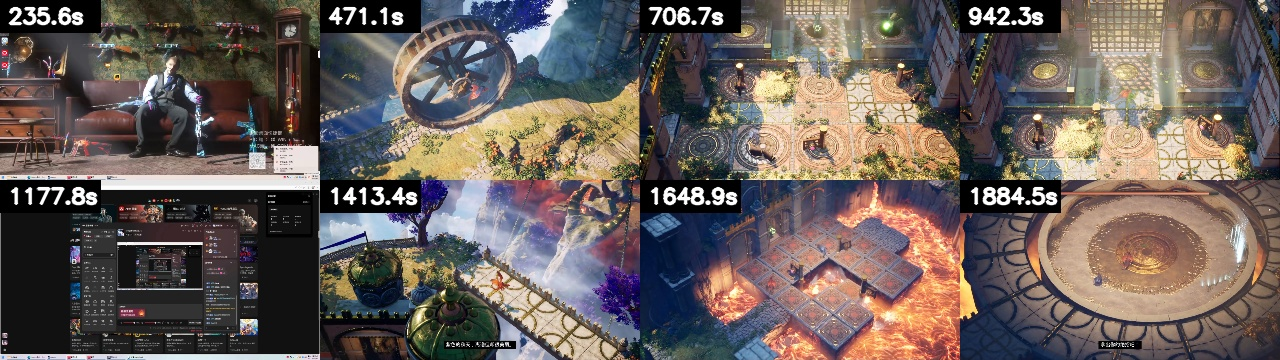

In [7]:
# =========================
# Cell 6. 单视频测试：仅 DEBUG 模式运行
# =========================

if DEBUG:
    from IPython.display import Image, display
    import json

    if not video_files:
        raise RuntimeError("没有找到视频文件，请检查 /kaggle/input 是否已经添加视频数据集。")

    # 清空旧 report，避免混在一起
    if REPORT_JSONL.exists():
        REPORT_JSONL.unlink()

    video_path = video_files[0]
    print("测试视频:", video_path)

    # 注意：run 返回的是 Run 对象，不是 dict
    single_run = narrato_video_understanding.run(
        kbench.llm,
        video_path=video_path,
    )

    print("Run 对象类型:", type(single_run))
    print("任务已执行。详细结果应写入:", REPORT_JSONL)

    # 检查 task 是否真的写出了 JSONL
    if not REPORT_JSONL.exists():
        raise RuntimeError(
            "没有生成 REPORT_JSONL。说明你还没有替换 Cell 5，"
            "或者 narrato_video_understanding() 里没有 append_jsonl(REPORT_JSONL, record)。"
        )

    # 读取最后一条详细结果
    with open(REPORT_JSONL, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    if not lines:
        raise RuntimeError("REPORT_JSONL 是空的，说明 task 没有成功写入结果。")

    last_record = json.loads(lines[-1])

    print("\n===== 视频理解结果 =====")
    print(json.dumps(last_record, indent=2, ensure_ascii=False))

    print("\n===== Storyboard 预览 =====")
    display(Image(filename=last_record["storyboard_path"]))
else:
    print("DEBUG=False，跳过 Cell 6 单视频测试。")

In [8]:
# =========================
# Cell 7. 批量评测 10 个视频
# =========================

if DEBUG:
    import pandas as pd
    import json
    from IPython.display import display

    # 清空旧 report，避免和 C6 的单视频结果混在一起
    if REPORT_JSONL.exists():
        REPORT_JSONL.unlink()

    # 先不要全量跑，先跑前 10 个
    sample_video_files = video_files[:10]

    eval_df = pd.DataFrame({
        "video_path": sample_video_files,
    })

    print("本次评测视频数量:", len(eval_df))
    display(eval_df)

    runs = narrato_video_understanding.evaluate(
        llm=[kbench.llm],
        evaluation_data=eval_df,
        max_attempts=2,
        retry_delay=5,
        remove_run_files=False,
    )

    # Kaggle Benchmark 自己的运行结果
    runs_df = runs.as_dataframe()
    print("===== Kaggle Run 结果 =====")
    display(runs_df)

    # 读取我们自己写出的详细理解结果
    records = []

    if REPORT_JSONL.exists():
        with open(REPORT_JSONL, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    records.append(json.loads(line))

    details_df = pd.DataFrame(records)

    print("===== NarratoAI 视频理解详细结果 =====")
    display(details_df)

    # 保存结果
    csv_path = RESULT_DIR / "narrato_video_understanding_details.csv"
    json_path = RESULT_DIR / "narrato_video_understanding_details.json"

    details_df.to_csv(csv_path, index=False)

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

    print("详细 CSV:", csv_path)
    print("详细 JSON:", json_path)
else:
    print("DEBUG=False，跳过 Cell 7 批量评测视频。")

本次评测视频数量: 4


,video_path
0,/kaggle/input/datasets/chrisezadi/together/par...
1,/kaggle/input/datasets/chrisezadi/together/par...
2,/kaggle/input/datasets/chrisezadi/together/par...
3,/kaggle/input/datasets/chrisezadi/together/par...


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:   47.3s finished


===== Kaggle Run 结果 =====


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:   51.3s finished


,llm,video_path,result,id
run_id,,,,
Run #6,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,True,0
Run #7,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,True,1
Run #8,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,True,2
Run #9,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,True,3


===== NarratoAI 视频理解详细结果 =====


,video_path,storyboard_path,duration,timestamps,summary,main_objects,main_actions,scene,screen_text,ost,ost_reason,narration
0,/kaggle/input/datasets/chrisezadi/together/par...,/kaggle/working/storyboards/part1_2e4290a2_sto...,2120.066667,"[235.56296296296296, 471.1259259259259, 706.68...",视频展示了一名博主的开场介绍及其在某款俯视角动作冒险游戏中的实机操作演示，包含多个不同环境的...,"[西装男博主, 皮质沙发, 枪械模型, 游戏角色, 巨大木轮, 庭院关卡, 熔岩关卡, 游戏...","[博主静坐在背景墙前, 角色在悬崖和庭院间穿梭, 操作大型滚动机械, 在熔岩路径上进行解谜]",游戏画面,"235.6s, 471.1s, 706.7s, 942.3s, 1177.8s, 1413....",2,视频包含游戏实机音效和背景音乐，适合保留环境音的同时由AI进行讲解。,跟随镜头深入探索这款画风精美的动作解谜游戏，体验奇幻多变的关卡挑战。
1,/kaggle/input/datasets/chrisezadi/together/par...,/kaggle/working/storyboards/part2_b3faf87b_sto...,2119.366667,"[235.4851851851852, 470.9703703703704, 706.455...",视频集锦展示了包含巨龙战斗、剧情对白、科幻场景探索以及软件界面操作在内的多种游戏画面。,"[巨龙, 游戏角色, 圆形竞技场, 科幻建筑内部, 电脑操作界面]","[在竞技场战斗, 巨龙咆哮与飞行, 角色之间的剧情对话, 场景切换与展示]",游戏画面与影视片段,不，没这事，别说这些。这里就是我们的地盘了。,2,画面涵盖了宏大的战斗场面与带字幕的角色对话，保留低音量原声可增强氛围感，同时适合叠加解说。,视频带我们穿梭于奇幻与科幻的游戏世界，见证了巨龙的威严与深刻的角色对白。
2,/kaggle/input/datasets/chrisezadi/together/par...,/kaggle/working/storyboards/part3_0cee1774_sto...,2117.866667,"[235.31851851851854, 470.6370370370371, 705.95...",这段视频展示了一段科幻工业风格游戏的解谜闯关过程，玩家操控发光的能量球在复杂的机械结构、管道...,"[发光能量球, 工业机械平台, 传送管道, 绿色液体池, 科幻控制面板]","[能量球在平台上滚动, 跨越机械障碍, 通过水池区域, 激活激光或能量装置]",游戏画面,"235.3s, 470.6s, 706.0s, 941.3s, 1176.6s, 1411....",0,视频为纯游戏操作画面展示，没有对话或必须保留的原声音频，适合配合纯AI解说。,穿梭在充满未来感的工业迷宫中，玩家需精准操控能量球，解开重重机械机关。
3,/kaggle/input/datasets/chrisezadi/together/par...,/kaggle/working/storyboards/part4_3a6a01df_sto...,2116.366667,"[235.15185185185186, 470.3037037037037, 705.45...",这段视频展示了一款科幻工业风格的平台解谜游戏玩法，玩家操控一个小球在复杂的机械迷宫和工厂设施...,"[能量小球, 工业管道, 机械齿轮, 传送带, 激光束, 红色能量体]","[穿梭, 躲避障碍, 沿轨道移动, 解谜导航]",游戏画面,"O/W, B-TRAK, F/F",0,视频内容为纯游戏演示画面，无人物对话，适合由AI解说完全覆盖。,玩家正操控着灵动的能量球，在精密的机械迷宫中小心穿梭，寻找通往出口的唯一路径。
4,/kaggle/input/datasets/chrisezadi/together/par...,/kaggle/working/storyboards/part1_2e4290a2_sto...,2120.066667,"[235.56296296296296, 471.1259259259259, 706.68...",视频展示了从现实风格的房间场景过渡到一款俯视角动作冒险游戏的游玩过程，包括角色在精美的遗迹、...,"[西装男子, 枪械收藏墙, 游戏菜单界面, 巨型石轮, 中式风格遗迹, 岩浆关卡, 圆形解谜平台]","[角色坐在沙发上展示环境, 通过菜单选择进入游戏, 在错综复杂的遗迹中移动, 操作旋转机关,...",游戏画面,"235.6s, 471.1s, 706.7s, 942.3s, 1177.8s, 1413....",2,视频展示了丰富的游戏场景和精美的关卡设计，保留低音量原声能增加代入感，配合解说效果更佳。,穿过满墙枪械的神秘房间，我们坠入奇幻的古老遗迹，在精巧的机关与炙热岩浆间寻找出路。
5,/kaggle/input/datasets/chrisezadi/together/par...,/kaggle/working/storyboards/part2_b3faf87b_sto...,2119.366667,"[235.4851851851852, 470.9703703703704, 706.455...",这段视频展示了高品质的奇幻游戏画面与剧情过场，包含巨龙战斗、角色对白及场景展示。,"[巨龙, 女性角色, 圆形竞技场, 管理界面, 工业建筑]","[竞技场对战, 巨龙飞行, 角色交谈, 展示软件界面, 场景切换]",游戏画面与影视片段,不，还没到，还没到那个时候。他们都已经不存在很久了。,2,画面中包含明显的剧情对白和环境氛围音效，适合在保留低音量原声的情况下叠加AI解说。,从燃尽一切的巨龙吐息，到扣人心弦的命运对白，每一帧都如同宏大的史诗画卷。
6,/kaggle/input/datasets/chrisezadi/together/par...,/kaggle/working/storyboards/part3_0cee1774_sto...,2117.866667,"[235.31851851851854, 470.6370370370371, 705.95...",这段视频展示了一款具有未来工业风格的解谜游戏过程，玩家在复杂的金属构架、管道和绿色毒液池之间...,"[发光能量球, 金属平台, 工业管道, 机械臂, 绿色毒液池, 游戏UI界面]","[在工业遗迹中探索, 在平台上跳跃移动, 观察复杂的机械结构, 在有毒液体上空谨慎行进]",游戏画面,"235.3s, 470.6s, 706.0s, 941.3s, 1176.6s, 1411....",0,视频内容为纯游戏操作演示，没有人物对话，适合使用纯AI解说覆盖原声。,玩家穿梭在冰冷的工业迷宫中，利用神秘的能量核心，解开重重机关以寻找出口。
7,/kaggle/input/datasets/chrisezadi/together/par...,/kaggle/working/storyboards/part4_3a6a01df_sto...,2116.366667,"[235.15185185185186, 470.3037037037037, 705.45...",玩家在充满机械感的工业场景中操作球形角色，穿梭、射击并对抗各种复杂的机械机关和敌对目标。,"[球形游戏角色, 工业传送带, 机械齿轮, 激光设施, 工厂背景]","[避开旋转齿轮, 发射激光射击, 在复杂机关中寻找出路]",游戏画面,"235.2s, 470.3s, 705.5s, 940.6s, 1175.8s, 1410....",0,视频为纯游戏实况画面，没有对话，适合由AI进行全程解说。,置身于这座钢铁丛林，你必须时刻保持警惕，灵活应对接踵而至的机械机关。


详细 CSV: /kaggle/working/results/narrato_video_understanding_details.csv
详细 JSON: /kaggle/working/results/narrato_video_understanding_details.json


In [9]:
# =========================
# 检查 C7 是否写出了结果
# =========================

if DEBUG:
    print("REPORT_JSONL:", REPORT_JSONL)
    print("exists:", REPORT_JSONL.exists())

    if REPORT_JSONL.exists():
        with open(REPORT_JSONL, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]
        
        print("写入记录数:", len(lines))
        
        for i, line in enumerate(lines):
            print(f"\n===== record {i} =====")
            record = json.loads(line)
            print(json.dumps(record, indent=2, ensure_ascii=False))
    else:
        print("还没有生成 report 文件")
else:
    print("DEBUG=False，跳过 C7 结果检查。")

REPORT_JSONL: /kaggle/working/results/narrato_video_understanding_report.jsonl
exists: True
写入记录数: 8

===== record 0 =====
{
  "video_path": "/kaggle/input/datasets/chrisezadi/together/part1.mp4",
  "storyboard_path": "/kaggle/working/storyboards/part1_2e4290a2_storyboard.jpg",
  "duration": 2120.0666666666666,
  "timestamps": [
    235.56296296296296,
    471.1259259259259,
    706.6888888888889,
    942.2518518518518,
    1177.8148148148148,
    1413.3777777777777,
    1648.9407407407407,
    1884.5037037037036
  ],
  "summary": "视频展示了一名博主的开场介绍及其在某款俯视角动作冒险游戏中的实机操作演示，包含多个不同环境的关卡场景。",
  "main_objects": [
    "西装男博主",
    "皮质沙发",
    "枪械模型",
    "游戏角色",
    "巨大木轮",
    "庭院关卡",
    "熔岩关卡",
    "游戏启动器"
  ],
  "main_actions": [
    "博主静坐在背景墙前",
    "角色在悬崖和庭院间穿梭",
    "操作大型滚动机械",
    "在熔岩路径上进行解谜"
  ],
  "scene": "游戏画面",
  "screen_text": "235.6s, 471.1s, 706.7s, 942.3s, 1177.8s, 1413.4s, 1648.9s, 1884.5s",
  "ost": 2,
  "ost_reason": "视频包含游戏实机音效和背景音乐，适合保留环境音的同时由AI进行讲解。",
  "narration": "跟随镜头

In [10]:
# =========================
# Cell 8. 生成视频片段索引
# =========================

import math
import pandas as pd
from pathlib import Path

SEGMENT_SECONDS = 30.0   # 每段 30 秒
MAX_SEGMENTS_PER_VIDEO = 20  # 先限制每个视频最多 20 段，避免一次跑太久


def build_video_segments(
    video_files,
    segment_seconds: float = 30.0,
    max_segments_per_video: int | None = None,
):
    rows = []

    for video_path in video_files:
        info = probe_video(video_path)
        duration = float(info["duration"])

        if duration <= 0:
            continue

        num_segments = math.ceil(duration / segment_seconds)

        if max_segments_per_video is not None:
            num_segments = min(num_segments, max_segments_per_video)

        for i in range(num_segments):
            start_sec = i * segment_seconds
            end_sec = min((i + 1) * segment_seconds, duration)

            if end_sec - start_sec < 3:
                continue

            rows.append({
                "video_path": video_path,
                "segment_index": i,
                "start_sec": round(start_sec, 2),
                "end_sec": round(end_sec, 2),
                "duration": round(end_sec - start_sec, 2),
            })

    return pd.DataFrame(rows)


segment_df = build_video_segments(
    video_files,
    segment_seconds=SEGMENT_SECONDS,
    max_segments_per_video=MAX_SEGMENTS_PER_VIDEO,
)

print("视频数量:", len(video_files))
print("片段数量:", len(segment_df))
display(segment_df.head(30))

视频数量: 4
片段数量: 80


,video_path,segment_index,start_sec,end_sec,duration
0,/kaggle/input/datasets/chrisezadi/together/par...,0,0.0,30.0,30.0
1,/kaggle/input/datasets/chrisezadi/together/par...,1,30.0,60.0,30.0
2,/kaggle/input/datasets/chrisezadi/together/par...,2,60.0,90.0,30.0
3,/kaggle/input/datasets/chrisezadi/together/par...,3,90.0,120.0,30.0
4,/kaggle/input/datasets/chrisezadi/together/par...,4,120.0,150.0,30.0
5,/kaggle/input/datasets/chrisezadi/together/par...,5,150.0,180.0,30.0
6,/kaggle/input/datasets/chrisezadi/together/par...,6,180.0,210.0,30.0
7,/kaggle/input/datasets/chrisezadi/together/par...,7,210.0,240.0,30.0
8,/kaggle/input/datasets/chrisezadi/together/par...,8,240.0,270.0,30.0
9,/kaggle/input/datasets/chrisezadi/together/par...,9,270.0,300.0,30.0


In [11]:
# =========================
# Cell 9. 针对单个片段抽帧并生成 storyboard
# =========================

def make_segment_storyboard(
    video_path: str,
    start_sec: float,
    end_sec: float,
    segment_index: int,
    output_dir: Path = STORYBOARD_DIR,
    num_frames: int = 6,
    cell_width: int = 320,
    cols: int = 3,
) -> dict:
    """
    对视频的 [start_sec, end_sec] 区间抽帧，生成 storyboard。
    不把时间戳画进图里，避免 VLM 把时间戳识别成 screen_text。
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"无法打开视频: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0 or total_frames <= 0:
        cap.release()
        raise RuntimeError(
            f"视频元信息异常: {video_path}, fps={fps}, total_frames={total_frames}"
        )

    video_duration = total_frames / fps
    start_sec = max(0.0, float(start_sec))
    end_sec = min(float(end_sec), video_duration)

    if end_sec <= start_sec:
        cap.release()
        raise RuntimeError(f"非法片段: start={start_sec}, end={end_sec}")

    seg_duration = end_sec - start_sec

    # 在片段内部均匀抽帧，避开片段首尾
    timestamps = [
        start_sec + seg_duration * (i + 1) / (num_frames + 1)
        for i in range(num_frames)
    ]

    frames = []
    valid_timestamps = []

    for t in timestamps:
        frame = read_frame_at_time(cap, fps, t)
        if frame is None:
            continue

        frame = resize_keep_ratio(frame, target_width=cell_width)

        frames.append(frame)
        valid_timestamps.append(round(t, 2))

    cap.release()

    if not frames:
        raise RuntimeError(
            f"没有抽出有效帧: {video_path}, start={start_sec}, end={end_sec}"
        )

    # 统一高度
    max_h = max(f.shape[0] for f in frames)
    normalized = []

    for f in frames:
        h, w = f.shape[:2]
        if h < max_h:
            pad_h = max_h - h
            f = cv2.copyMakeBorder(
                f,
                0,
                pad_h,
                0,
                0,
                cv2.BORDER_CONSTANT,
                value=(255, 255, 255),
            )
        normalized.append(f)

    rows = math.ceil(len(normalized) / cols)
    blank = np.ones_like(normalized[0]) * 255

    grid_rows = []
    for r in range(rows):
        row_imgs = []
        for c in range(cols):
            idx = r * cols + c
            if idx < len(normalized):
                row_imgs.append(normalized[idx])
            else:
                row_imgs.append(blank.copy())
        grid_rows.append(cv2.hconcat(row_imgs))

    storyboard = cv2.vconcat(grid_rows)

    video_id = safe_video_id(video_path)
    out_path = output_dir / f"{video_id}_seg{segment_index:04d}_{start_sec:.1f}_{end_sec:.1f}.jpg"

    ok = cv2.imwrite(str(out_path), storyboard)
    if not ok:
        raise RuntimeError(f"storyboard 写入失败: {out_path}")

    return {
        "video_path": video_path,
        "storyboard_path": str(out_path),
        "segment_index": segment_index,
        "start_sec": round(start_sec, 2),
        "end_sec": round(end_sec, 2),
        "duration": round(seg_duration, 2),
        "timestamps": valid_timestamps,
    }

In [12]:
# =========================
# Cell 10. 片段级视频理解 Task
# =========================

SEGMENT_REPORT_JSONL = RESULT_DIR / "narrato_segment_understanding_report.jsonl"


@kbench.task(
    name="NarratoAI Segment Video Understanding",
    description=(
        "Evaluate whether a multimodal LLM can understand a short video segment "
        "from sampled frames and generate NarratoAI script metadata."
    ),
)
def narrato_segment_understanding(
    llm,
    video_path: str,
    segment_index: int,
    start_sec: float,
    end_sec: float,
) -> bool:
    storyboard_info = make_segment_storyboard(
        video_path=video_path,
        start_sec=start_sec,
        end_sec=end_sec,
        segment_index=int(segment_index),
        output_dir=STORYBOARD_DIR,
        num_frames=6,
        cell_width=320,
        cols=3,
    )

    img = images.from_path(storyboard_info["storyboard_path"])

    prompt = f"""
你正在为 NarratoAI 做视频片段理解。

当前视频片段时间范围：
start_sec = {start_sec}
end_sec = {end_sec}

下面这张图片是该视频片段内部按时间顺序抽取的关键帧拼图。
请注意：图片中如果出现时间戳、帧编号、采样标签，不属于原始视频画面文字，必须忽略，不要写入 screen_text。

请根据画面内容输出结构化结果。

你需要完成：

1. summary:
   用中文概括这个片段发生了什么。

2. main_objects:
   列出主要人物、物体、地点元素。

3. main_actions:
   列出主要动作变化。

4. scene:
   判断场景类型，例如游戏画面、室内、街道、会议、影视片段等。

5. screen_text:
   只提取原始视频画面中真实存在的文字。
   不要提取 storyboard 上的时间戳、帧编号、采样标签。
   如果没有真实画面文字，返回空字符串。

6. ost:
   判断 NarratoAI 的 OST 策略：
   - 0：纯 AI 解说，原声静音
   - 1：保留原声，不加旁白
   - 2：保留低音量原声，同时叠加 AI 解说

   判断规则：
   - 普通画面展示、动作过程、游戏实况、无明显口播：优先 ost=0。
   - 明显采访、演讲、人物对话、口型强烈依赖原声：ost=1。
   - 有明显环境氛围、音乐场景、现场感，但仍适合加旁白：ost=2。
   - 仅凭画面无法确认有人说话时，不要强行设为 ost=1。

7. ost_reason:
   用一句话解释为什么选择这个 OST。

8. narration:
   生成一句适合中文视频解说的旁白。
   要自然、简洁、有叙事感，长度控制在 20～45 个中文字符。

要求：
- 不要编造画面中不存在的信息。
- 不要输出 Markdown。
- 不要输出多余解释。
"""

    result = llm.prompt(
        prompt,
        image=img,
        schema=NarratoVideoUnderstanding,
    )

    kbench.assertions.assert_true(
        result.ost in [0, 1, 2],
        expectation="ost 必须是 0、1、2 之一。",
    )

    kbench.assertions.assert_true(
        len(result.summary.strip()) >= 5,
        expectation="summary 不能过短。",
    )

    kbench.assertions.assert_true(
        len(result.narration.strip()) >= 5,
        expectation="narration 不能过短。",
    )

    kbench.assertions.assert_true(
        len(result.narration.strip()) <= 90,
        expectation="narration 不应过长，避免 TTS 超出片段时长。",
    )

    record = {
        "video_path": video_path,
        "segment_index": int(segment_index),
        "start": float(start_sec),
        "end": float(end_sec),
        "duration": float(end_sec) - float(start_sec),
        "ost": int(result.ost),
        "text": result.narration,
        "summary": result.summary,
        "scene": result.scene,
        "main_objects": result.main_objects,
        "main_actions": result.main_actions,
        "screen_text": result.screen_text,
        "ost_reason": result.ost_reason,
        "storyboard": storyboard_info["storyboard_path"],
        "sample_timestamps": storyboard_info["timestamps"],
        "source_video": video_path,
    }

    append_jsonl(SEGMENT_REPORT_JSONL, record)

    return True

In [13]:
# =========================
# Cell 11. 批量跑片段级理解：修正版
# =========================

if DEBUG:
    from IPython.display import display
    import json
    import pandas as pd

    if SEGMENT_REPORT_JSONL.exists():
        SEGMENT_REPORT_JSONL.unlink()

    # 只保留 task 函数签名里存在的列
    eval_segment_df = segment_df.head(8)[[
        "video_path",
        "segment_index",
        "start_sec",
        "end_sec",
    ]].copy()

    print("本次片段数量:", len(eval_segment_df))
    display(eval_segment_df)

    runs = narrato_segment_understanding.evaluate(
        llm=[kbench.llm],
        evaluation_data=eval_segment_df,
        max_attempts=2,
        retry_delay=5,
        remove_run_files=False,
    )

    runs_df = runs.as_dataframe()
    print("===== Kaggle Run 结果 =====")
    display(runs_df)

    records = []
    if SEGMENT_REPORT_JSONL.exists():
        with open(SEGMENT_REPORT_JSONL, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    records.append(json.loads(line))

    segment_details_df = pd.DataFrame(records)

    print("===== 片段级理解结果 =====")
    display(segment_details_df)

    segment_csv_path = RESULT_DIR / "narrato_segment_understanding_details.csv"
    segment_json_path = RESULT_DIR / "narrato_segment_understanding_details.json"

    segment_details_df.to_csv(segment_csv_path, index=False)

    with open(segment_json_path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

    print("片段级 CSV:", segment_csv_path)
    print("片段级 JSON:", segment_json_path)
else:
    print("DEBUG=False，跳过 Cell 11 片段级批量理解。")

本次片段数量: 8


,video_path,segment_index,start_sec,end_sec
0,/kaggle/input/datasets/chrisezadi/together/par...,0,0.0,30.0
1,/kaggle/input/datasets/chrisezadi/together/par...,1,30.0,60.0
2,/kaggle/input/datasets/chrisezadi/together/par...,2,60.0,90.0
3,/kaggle/input/datasets/chrisezadi/together/par...,3,90.0,120.0
4,/kaggle/input/datasets/chrisezadi/together/par...,4,120.0,150.0
5,/kaggle/input/datasets/chrisezadi/together/par...,5,150.0,180.0
6,/kaggle/input/datasets/chrisezadi/together/par...,6,180.0,210.0
7,/kaggle/input/datasets/chrisezadi/together/par...,7,210.0,240.0


[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:  1.3min


[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:  1.5min finished


[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:  1.1min


...

[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:  1.3min finished


,llm,video_path,segment_index,start_sec,end_sec,result,id
run_id,,,,,,,
Run #9,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,0,0.0,30.0,True,0
Run #10,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,1,30.0,60.0,True,1
Run #11,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,2,60.0,90.0,True,2
Run #12,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,3,90.0,120.0,True,3
Run #13,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,4,120.0,150.0,True,4
Run #14,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,5,150.0,180.0,True,5
Run #15,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,6,180.0,210.0,True,6
Run #16,🤖 google/gemini-3-flash-preview,/kaggle/input/datasets/chrisezadi/together/par...,7,210.0,240.0,True,7


===== 片段级理解结果 =====


,video_path,segment_index,start,end,duration,ost,text,summary,scene,main_objects,main_actions,screen_text,ost_reason,storyboard,sample_timestamps,source_video
0,/kaggle/input/datasets/chrisezadi/together/par...,0,0.0,30.0,30.0,0,我们现在正处于创作平台的启动页面，系统正在加载各项功能模块，简洁的界面设计让视频剪辑触手可及。,画面展示了一个视频剪辑或AI创作软件的启动与资源加载过程，呈现了其功能菜单和工作界面。,软件界面演示,"[软件操作界面, 进度条, 导航栏, 视频预览区域]","[系统资源加载, 界面元素初始化]","正在加载..., 首页, 我的内容, 开始创作, 回收站",该片段为纯软件界面操作展示，没有人物口播或现场对话，适合使用纯AI旁白进行讲解。,/kaggle/working/storyboards/part1_2e4290a2_seg...,"[4.29, 8.57, 12.86, 17.14, 21.43, 25.71]",/kaggle/input/datasets/chrisezadi/together/par...
1,/kaggle/input/datasets/chrisezadi/together/par...,1,30.0,60.0,30.0,0,画面中游戏正在加载，随后“双影奇境”四个大字伴随光效浮现，预示着奇幻旅程的开始。,视频展示了游戏的加载过程以及名为“双影奇境”的标题画面呈现。,游戏UI加载界面,"[双影奇境艺术字, 加载进度条, 深邃星空背景, UI提示文字]","[游戏资源正在加载, 标题文字伴随光效浮现, 系统进行版本内容检查]","正在加载..., 双影奇境, 正在检查版本内容...",画面为纯粹的游戏加载与标题UI展示，无原声对话或特定现场音效，适合纯AI解说。,/kaggle/working/storyboards/part1_2e4290a2_seg...,"[34.29, 38.57, 42.86, 47.14, 51.43, 55.71]",/kaggle/input/datasets/chrisezadi/together/par...
2,/kaggle/input/datasets/chrisezadi/together/par...,2,60.0,90.0,30.0,0,现在进入到了游戏的连接准备阶段，玩家可以在此界面选择操作设备，并快速进入不同的频道。,这个片段展示了游戏的连接界面，玩家可以选择输入设备并进入不同的游戏功能频道。,游戏画面,"[游戏菜单界面, 输入设备图标, 功能按钮, 模糊街景背景]","[展示设备选择选项, 显示功能菜单栏]",连上游戏 本地键盘 控制器 刷新频道 创建频道 进入房间 设置,画面为静态的游戏菜单界面，没有人物口播或重要环境音，适合纯AI解说模式。,/kaggle/working/storyboards/part1_2e4290a2_seg...,"[64.29, 68.57, 72.86, 77.14, 81.43, 85.71]",/kaggle/input/datasets/chrisezadi/together/par...
3,/kaggle/input/datasets/chrisezadi/together/par...,3,90.0,120.0,30.0,0,用户正在浏览云游戏平台的菜单，界面简洁明了，可以快速切换外设模式或查看当前网络延迟。,用户正在操作云游戏或远程桌面管理平台的菜单界面，展示了线上游戏的选择和外设配置选项。,游戏画面,"[软件菜单界面, 背景街景, 鼠标光标, 功能按钮, 网络监控窗口]","[鼠标在界面上移动, 选择线上游戏模块, 查看外设连接状态]",线上游戏 外设模式 推荐游戏 我的游戏 公共频道 设置 RTT,视频主要展示软件UI操作过程，没有原声对话或特定音效需求，适合纯旁白叙述。,/kaggle/working/storyboards/part1_2e4290a2_seg...,"[94.29, 98.57, 102.86, 107.14, 111.43, 115.71]",/kaggle/input/datasets/chrisezadi/together/par...
4,/kaggle/input/datasets/chrisezadi/together/par...,4,120.0,150.0,30.0,0,选定心仪的角色后，我们随主人公坠入这片神秘荒野。面对突如其来的变故，一场未知的冒险正悄然拉开序幕。,这段片段展示了游戏的选人界面以及进入游戏后的剧情过场，包括角色的特写镜头和在遗迹场景中的初步探索。,游戏画面,"[游戏角色, 选择菜单, 草地, 岩石建筑, 奇异植物]","[选择游戏角色, 角色在地面上挣扎, 观察环境, 在遗迹中行走]","选择角色, 正在加载..., 等，这到底是怎么回事？一个果子。",片段主要由游戏菜单界面和过场剧情组成，没有明显的真人对话，适合配合AI解说来叙述背景。,/kaggle/working/storyboards/part1_2e4290a2_seg...,"[124.29, 128.57, 132.86, 137.14, 141.43, 145.71]",/kaggle/input/datasets/chrisezadi/together/par...
5,/kaggle/input/datasets/chrisezadi/together/par...,5,150.0,180.0,30.0,0,在破碎的空中遗迹中，角色顶着突如其来的爆炸光影不断探索，在险峻的悬崖间寻找着前进的方向。,在游戏画面中，一个龙形角色在悬崖和古老石径间穿行，期间经历了强烈的爆炸特效，并进行了攀爬和休...,游戏画面,"[龙形角色, 悬崖峭壁, 石块小径, 植被墙, 爆炸特效, 游戏菜单界面]","[攀爬墙壁, 石径行走, 躲避爆炸, 降落休息]",我在不？这是哪？,该片段为纯粹的游戏实况画面，无人物对话或特定原声依赖，适合完全由AI解说覆盖。,/kaggle/working/storyboards/part1_2e4290a2_seg...,"[154.29, 158.57, 162.86, 167.14, 171.43, 175.71]",/kaggle/input/datasets/chrisezadi/together/par...
6,/kaggle/input/datasets/chrisezadi/together/par...,6,180.0,210.0,30.0,0,红色飞龙在壮丽的奇幻世界中自由穿梭，从云海之巅到幽静的古城废墟，每一帧都如同史诗大片。,画面展示了一只红色飞龙在不同的奇幻场景中穿梭探索，包括云端悬崖和繁花似锦的古老遗迹。,游戏画面,"[红色飞龙, 云海, 石质建筑, 雕像, 繁茂的花草, 性能监测面板]","[飞翔, 地面行走, 产生传送光效, 观察环境]",RTX 4090 DLSS 3 DLSS Frame Generation Ray Reco...,该片段为典型的游戏画面展示，无人物对话或特定原声依赖，适合纯旁白解说。,/kaggle/working/storyboards/part1_2e4290a2_seg...,"[184.29, 188.57, 192.86, 197.14, 201.43, 205.71]",/kaggle/input/datasets/chrisezadi/together/par...
7,/kaggle/input/datasets/chrisezadi/together/par...,7,210.0,240.0,30.0,0,巨龙在神秘的奇幻遗迹中自在穿行，然而画面突转，展现在眼前的是一整面墙的步枪收藏壁纸。,视频展示了巨龙角色在奇幻风格的遗迹中探索、移动的过程，最后画面切换到了一个展示步枪收藏和人物...,游戏画面及电脑桌面,"[巨龙, 奇幻建筑遗迹, 发光装置, 电脑桌面壁纸, 步枪模型, 沙发上的男人]","[巨龙在石砖地面上跑动, 展示游戏内环境, 切换至电脑桌面画面]",暂存 进入游戏 多人游戏联机 设置 退出 那时候，我可以为您找到工作吗？,画面主要为游戏实况和桌面展示，没有真人对话或需要保留的特定原声，适合纯AI解说。,/kaggle/working/storyboards/part1_2e4290a2_seg...,"[214.29, 218.57, 222.86, 227.14, 231.43, 235.71]",/kaggle/input/datasets/chrisezadi/together/par...
8,/kaggle/input/datasets/chrisezadi/together/par...,0,0.0,30.0,30.0,0,我们现在看到软件正在进行数据加载，底部的进度条显示后台任务正在稳步推进。,这段视频展示了一个软件的录屏画面，最初显示的是功能丰富的编辑器界面，随后画面切换到带有进度条...,电脑屏幕录制,"[软件界面, 进度条, 加载提示符, 功能面板]","[打开编辑器, 进入加载页面, 进度条推进]",正在加载...,该片段为

片段级 CSV: /kaggle/working/results/narrato_segment_understanding_details.csv
片段级 JSON: /kaggle/working/results/narrato_segment_understanding_details.json


In [14]:
# =========================
# Cell 12. 生成 NarratoAI script JSON：去重版
# =========================

if DEBUG:
    records = []

    with open(SEGMENT_REPORT_JSONL, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))

    # 按 source_video + start + end 去重
    dedup = {}

    for r in records:
        key = (
            r["source_video"],
            round(float(r["start"]), 2),
            round(float(r["end"]), 2),
        )
        dedup[key] = r

    records = list(dedup.values())

    # 按视频和时间排序
    records = sorted(
        records,
        key=lambda x: (x["source_video"], float(x["start"]), float(x["end"]))
    )

    script = []

    for i, r in enumerate(records):
        script.append({
            "index": i,
            "start": round(float(r["start"]), 2),
            "end": round(float(r["end"]), 2),
            "duration": round(float(r["duration"]), 2),
            "ost": int(r["ost"]),
            "text": r["text"],
            "summary": r["summary"],
            "scene": r["scene"],
            "main_objects": r["main_objects"],
            "main_actions": r["main_actions"],
            "screen_text": r["screen_text"],
            "source_video": r["source_video"],
            "storyboard": r["storyboard"],
        })

    script_path = RESULT_DIR / "narrato_segment_script.json"

    with open(script_path, "w", encoding="utf-8") as f:
        json.dump(script, f, ensure_ascii=False, indent=2)

    print("原始记录数:", len(records))
    print("NarratoAI script 已保存:", script_path)
    print("script segment 数量:", len(script))
    print(json.dumps(script[:5], indent=2, ensure_ascii=False))
else:
    print("DEBUG=False，跳过 Cell 12 script 导出调试。")

原始记录数: 8
NarratoAI script 已保存: /kaggle/working/results/narrato_segment_script.json
script segment 数量: 8
[
  {
    "index": 0,
    "start": 0.0,
    "end": 30.0,
    "duration": 30.0,
    "ost": 0,
    "text": "我们现在看到软件正在进行数据加载，底部的进度条显示后台任务正在稳步推进。",
    "summary": "这段视频展示了一个软件的录屏画面，最初显示的是功能丰富的编辑器界面，随后画面切换到带有进度条的加载状态。",
    "scene": "电脑屏幕录制",
    "main_objects": [
      "软件界面",
      "进度条",
      "加载提示符",
      "功能面板"
    ],
    "main_actions": [
      "打开编辑器",
      "进入加载页面",
      "进度条推进"
    ],
    "screen_text": "正在加载...",
    "source_video": "/kaggle/input/datasets/chrisezadi/together/part1.mp4",
    "storyboard": "/kaggle/working/storyboards/part1_2e4290a2_seg0000_0.0_30.0.jpg"
  },
  {
    "index": 1,
    "start": 30.0,
    "end": 60.0,
    "duration": 30.0,
    "ost": 0,
    "text": "随着加载进度条的推进，华丽的“双影奇境”标题映入眼帘，宣告全新的排位竞技模式正式开启。",
    "summary": "视频片段展示了游戏加载界面向主标题“双影奇境”的平滑过渡，并显示排位竞技模式已发布的提示。",
    "scene": "游戏加载与标题界面",
    "main_objects": [
      "加载进度条",
      "发光晶体图标",
      "“双影

In [15]:
%choose narrato_segment_understanding

Kept: NarratoAI_Segment_Video_Understanding.task.json
Kept: NarratoAI_Segment_Video_Understanding-run_param_id_7_google_gemini-3-flash-preview.run.json
